In [32]:
#Import thư viện cho cả 3 thuật toán
#-------Cho KMeans--------
import matplotlib.pyplot as plt
import pandas as pd
from cuml.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score,silhouette_samples
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
#from sklearn_extra.cluster import KMedoids
#from sklearn.neighbors import NearestNeighbors
from cuml.neighbors import NearestNeighbors
import matplotlib.cm as cm
import joblib



In [2]:
#======Các tham số chung=========
Dataset_path="/workspace/dataset_final.csv"
save_path = "workspace/AnhKetQuaClustering"
#Load dataset
df_preprocessed = pd.read_csv(Dataset_path)
X = df_preprocessed.values

***Ý nghĩa các chỉ số đánh giá chung***
1. Silhouette Score: Một điểm dữ liệu có thực sự thuộc về cụm đó hay không
2. Calinski Harabasz: Các cụm có cách xa nhau hay không. Mỗi cụm có đủ chặt hay không
3. Devies-Bouldin Index: Mỗi cụm giống cụm gần nhất đến mức nào

**K-MEANS**

**K-MEDIODS**???

**DBSCAN**

In [5]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 13,
    'figure.dpi': 300,
    'savefig.dpi': 300,
})

df = df_preprocessed.copy()
X = df.values


Tính khoảng cách K-NN với k=18


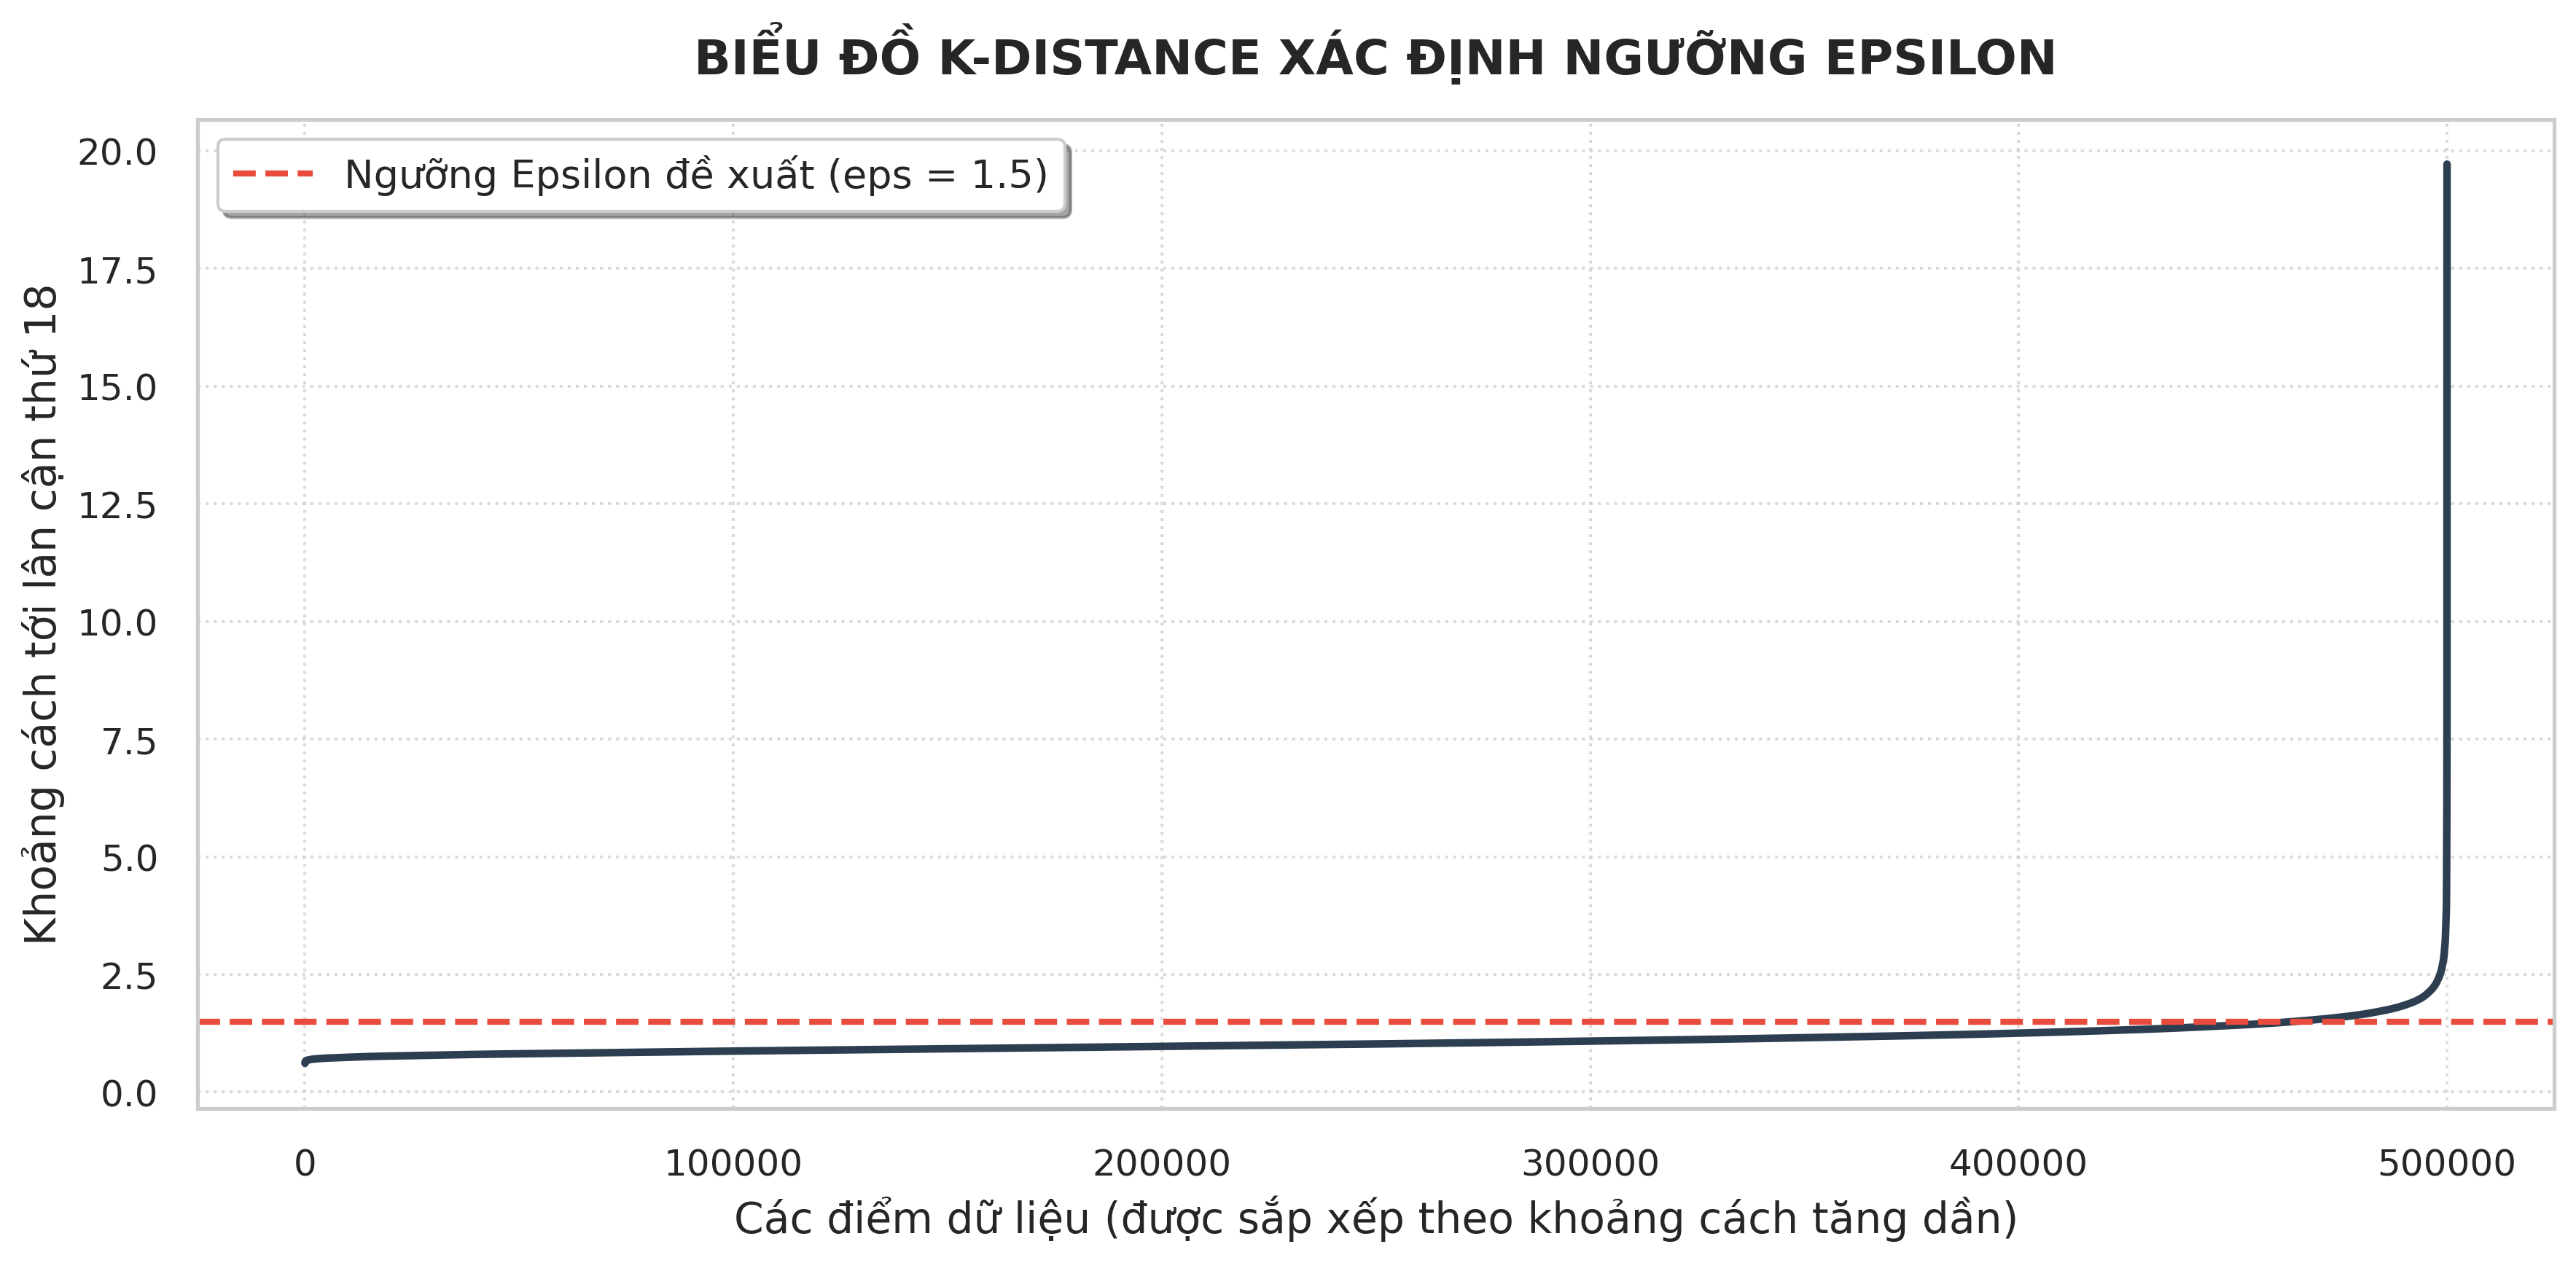

In [33]:


#TÌM THAM SỐ EPSILON TỐI ƯU
min_pts = 18 #Tính theo công thức min_pts >= 2*D (D= số chiều dữ liệu)
print(f"\nTính khoảng cách K-NN với k={min_pts}")

neighbors = NearestNeighbors(n_neighbors=min_pts)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)
distances = np.sort(distances[:, min_pts-1], axis=0)

fig1 = plt.figure(figsize=(12, 6))
plt.plot(distances, color='#2c3e50', linewidth=2.5)
plt.title('BIỂU ĐỒ K-DISTANCE XÁC ĐỊNH NGƯỠNG EPSILON', fontweight='bold', pad=15)
plt.xlabel('Các điểm dữ liệu (được sắp xếp theo khoảng cách tăng dần)')
plt.ylabel(f'Khoảng cách tới lân cận thứ {min_pts}')
plt.axhline(y=1.5, color='#e74c3c', linestyle='--', linewidth=2, label='Ngưỡng Epsilon đề xuất (eps = 1.5)')
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [34]:
#THỰC THI THUẬT TOÁN DBSCAN
#Test trên danh sách 1.3 1.5 1.7 2.0 2.2
min_pts = 18
eps_value = 1.7
dbscan = DBSCAN(eps=eps_value, min_samples=min_pts)
clusters = dbscan.fit_predict(X)
df['Cluster'] = clusters
df['Nhãn_Hành_Vi'] = df['Cluster'].apply(lambda x: 'Bất thường' if x == -1 else 'Bình thường')

Đã lưu Scatter Plot


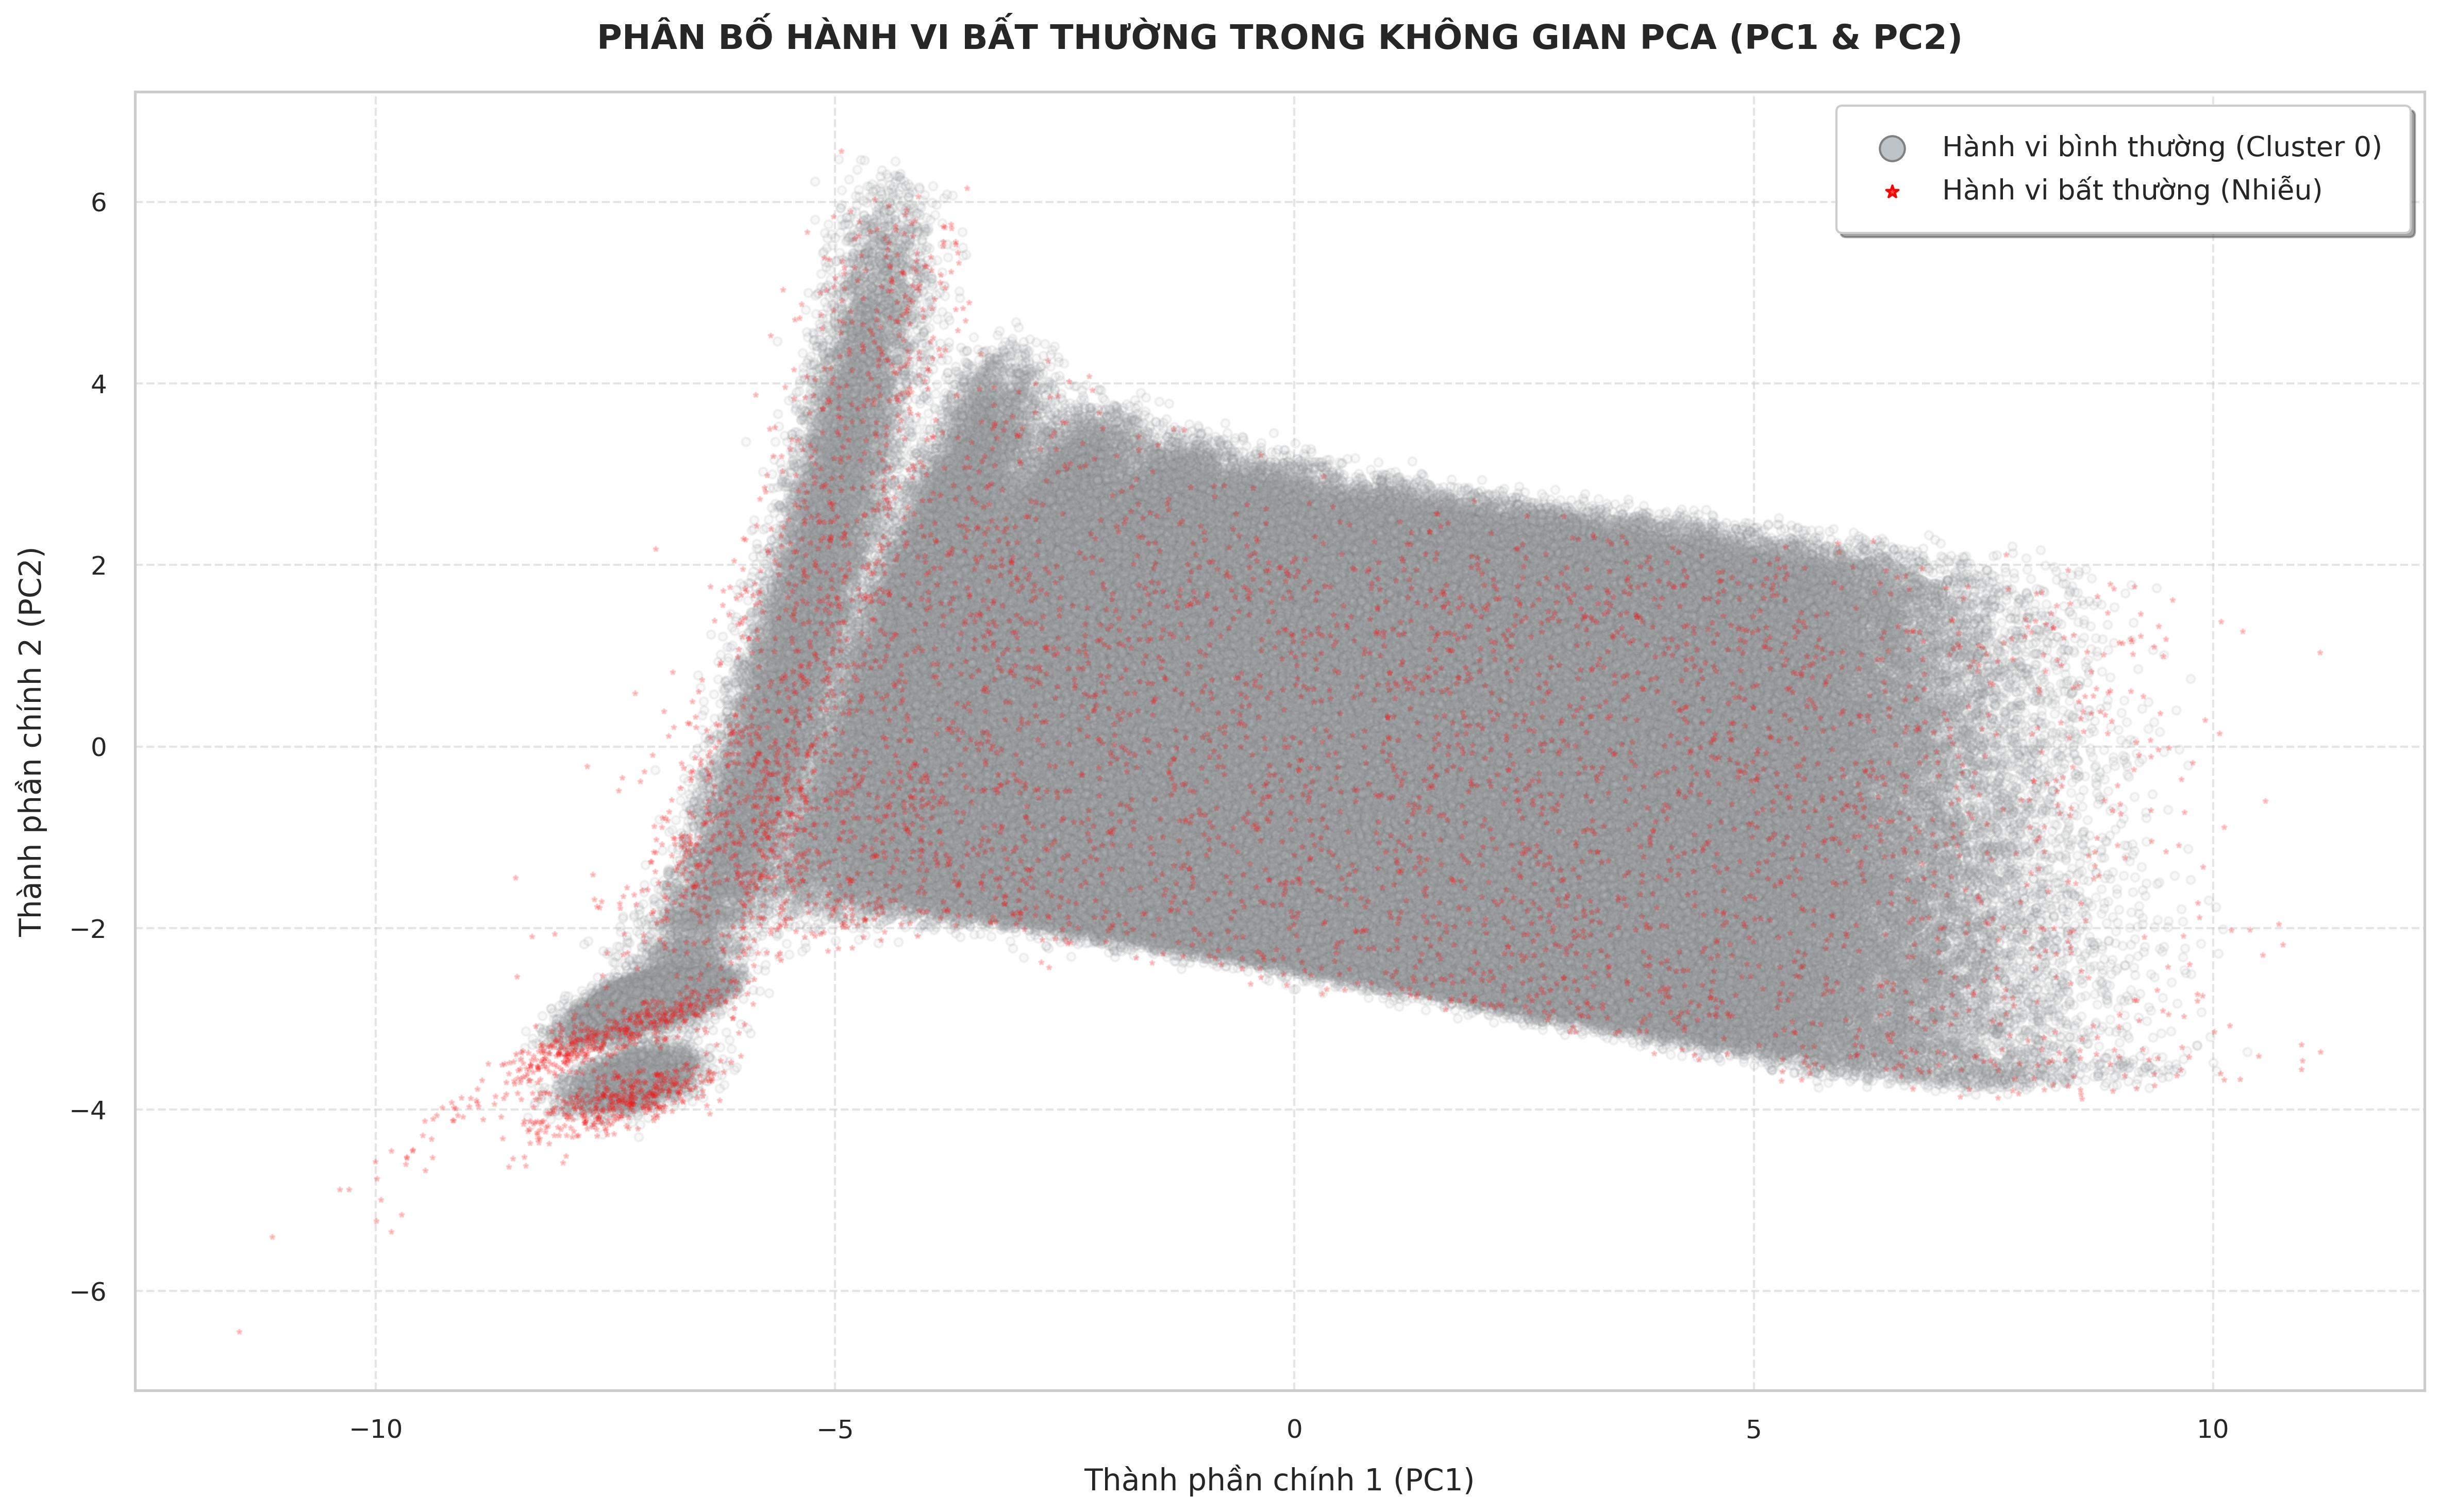

Đã lưu Boxplot


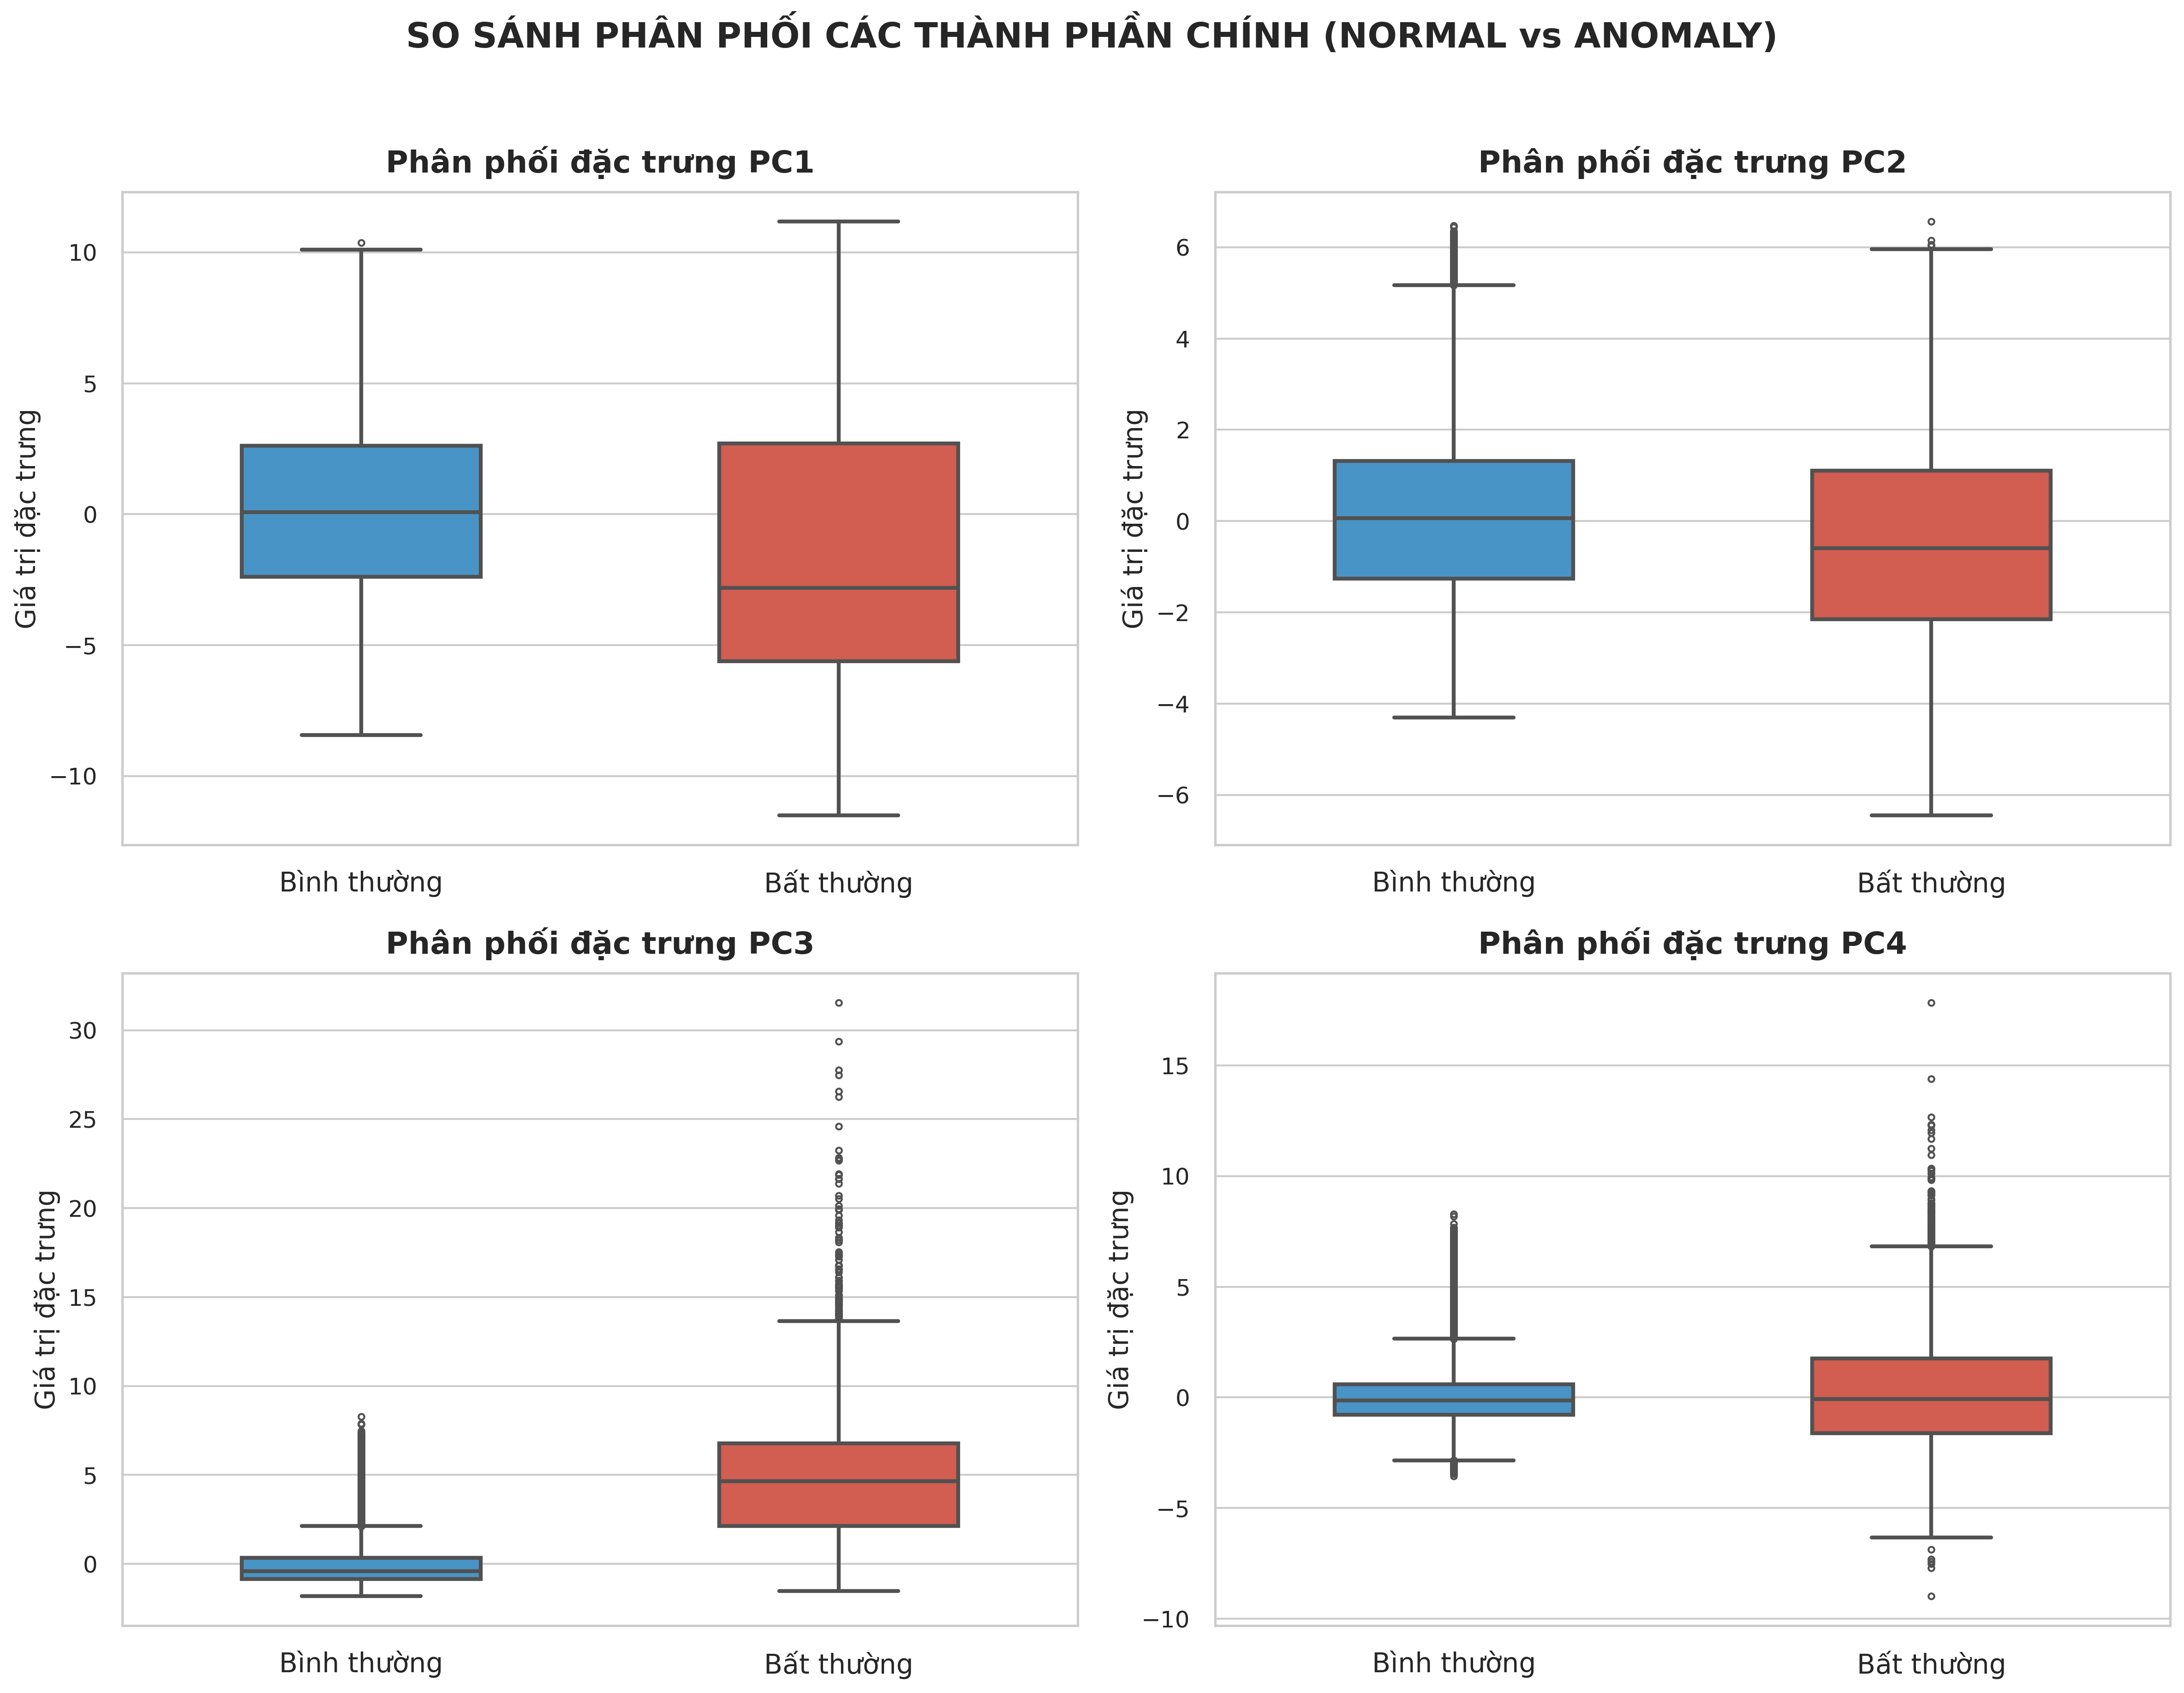


 LƯU FILE CSV THÀNH CÔNG!
 File dữ liệu đã lưu tại: /workspace/DBSCAN_1.7EpsValue_result.csv


In [35]:
#RỰC QUAN HÓA 2D BẢN ĐỒ PHÂN BỐ (SCATTER PLOT)
fig2 = plt.figure(figsize=(16, 10))
normal_data = df[df['Cluster'] != -1]
anomaly_data = df[df['Cluster'] == -1]

# Lớp nền: Điểm bình thường
plt.scatter(normal_data['PC1'], normal_data['PC2'], color='#bdc3c7', s=15, alpha=0.1, label='Hành vi bình thường (Cluster 0)', edgecolors='grey')

# Lớp trên: Điểm bất thường
plt.scatter(anomaly_data['PC1'], anomaly_data['PC2'], color='#e74c3c', marker='*', s=4, alpha=0.2, edgecolors='red', linewidths=1.0, label='Hành vi bất thường (Nhiễu)')

plt.title('PHÂN BỐ HÀNH VI BẤT THƯỜNG TRONG KHÔNG GIAN PCA (PC1 & PC2)', fontweight='bold', pad=20)
plt.xlabel('Thành phần chính 1 (PC1)', labelpad=10)
plt.ylabel('Thành phần chính 2 (PC2)', labelpad=10)

leg = plt.legend(loc='upper right', frameon=True, shadow=True, borderpad=1, markerscale=3.0)
for lh in leg.legend_handles: 
    lh.set_alpha(1)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

#Bản đồ phân bố Scatter Plot 
plt.savefig(f"/workspace/AnhKetQuaClustering/DBSCAN_{eps_value}EpsValue_Scatter_Distribution.png", dpi=300, bbox_inches='tight')
print("Đã lưu Scatter Plot")
plt.show()


#ĐÁNH GIÁ PHÂN PHỐI BẰNG BOXPLOT
features_to_plot = ['PC1', 'PC2', 'PC3', 'PC4']
fig3 = plt.figure(figsize=(16, 12))

for i, feature in enumerate(features_to_plot, 1):
    ax = plt.subplot(2, 2, i)
    # Thêm tham số hue để tránh cảnh báo (Warning) của Seaborn
    sns.boxplot(x='Nhãn_Hành_Vi', y=feature, hue='Nhãn_Hành_Vi', data=df, 
                palette={'Bình thường': '#3498db', 'Bất thường': '#e74c3c'}, 
                width=0.5, linewidth=2, fliersize=3, legend=False)
    plt.title(f'Phân phối đặc trưng {feature}', fontweight='bold', pad=10)
    plt.xlabel('')
    plt.ylabel('Giá trị đặc trưng')
    ax.tick_params(axis='x', labelsize=14)

plt.suptitle('SO SÁNH PHÂN PHỐI CÁC THÀNH PHẦN CHÍNH (NORMAL vs ANOMALY)', fontweight='bold', fontsize=18, y=1.02)
plt.tight_layout()

# LƯU ẢNH 2: Biểu đồ Boxplot
plt.savefig(f"/workspace/AnhKetQuaClustering/DBSCAN_{eps_value}EpsValue_Boxplot_Comparison.png", dpi=300, bbox_inches='tight')
print("Đã lưu Boxplot")
plt.show()



# LƯU TẬP KẾT QUẢ DỮ LIỆU
output_file_path = f"/workspace/DBSCAN_{eps_value}EpsValue_result.csv"
try:
    df.to_csv(output_file_path, index=False)
    print("\n" + "=" * 50)
    print(" LƯU FILE CSV THÀNH CÔNG!")
    print(f" File dữ liệu đã lưu tại: {output_file_path}")
    print("=" * 50)
except Exception as e:
    print(f" LỖI TRONG QUÁ TRÌNH LƯU TỆP CSV: {str(e)}")

In [36]:
#Lấy ngẫu nhiên 50000 mẫu để đánh giá
df_sample_metrics = df.sample(n=50000, random_state=42)
X_sample_metrics = df_sample_metrics[['PC1', 'PC2', 'PC3', 'PC4']].values
labels_sample_metrics = df_sample_metrics['Cluster'].values

In [37]:
# Tính chỉ số Silhouette Score tổng thể cho DBSCAN -> Càng gần 1 càng tốt
score = silhouette_score(X_sample_metrics, labels_sample_metrics, random_state=42)
print(f"1. Chỉ số Silhouette Score tổng thể (DBSCAN): {score:.4f}")

# Tính chỉ số Calinski–Harabasz Index -> Càng lớn càng tốt
ch_index = calinski_harabasz_score(X_sample_metrics, labels_sample_metrics)
print(f"2. Chỉ số Calinski–Harabasz Index (DBSCAN): {ch_index:.2f}")

# Tính chỉ số Davies–Bouldin Index -> Càng nhỏ càng tốt
db_index = davies_bouldin_score(X_sample_metrics, labels_sample_metrics)
print(f"3. Chỉ số Davies–Bouldin Index (DBSCAN): {db_index:.4f}")

1. Chỉ số Silhouette Score tổng thể (DBSCAN): 0.4284
2. Chỉ số Calinski–Harabasz Index (DBSCAN): 865.44
3. Chỉ số Davies–Bouldin Index (DBSCAN): 1.9120


-> Đã lưu biểu đồ thành công tại: /workspace/AnhKetQuaClustering/DBSCAN_1.7EpsValue_Silhouette_Graph.png


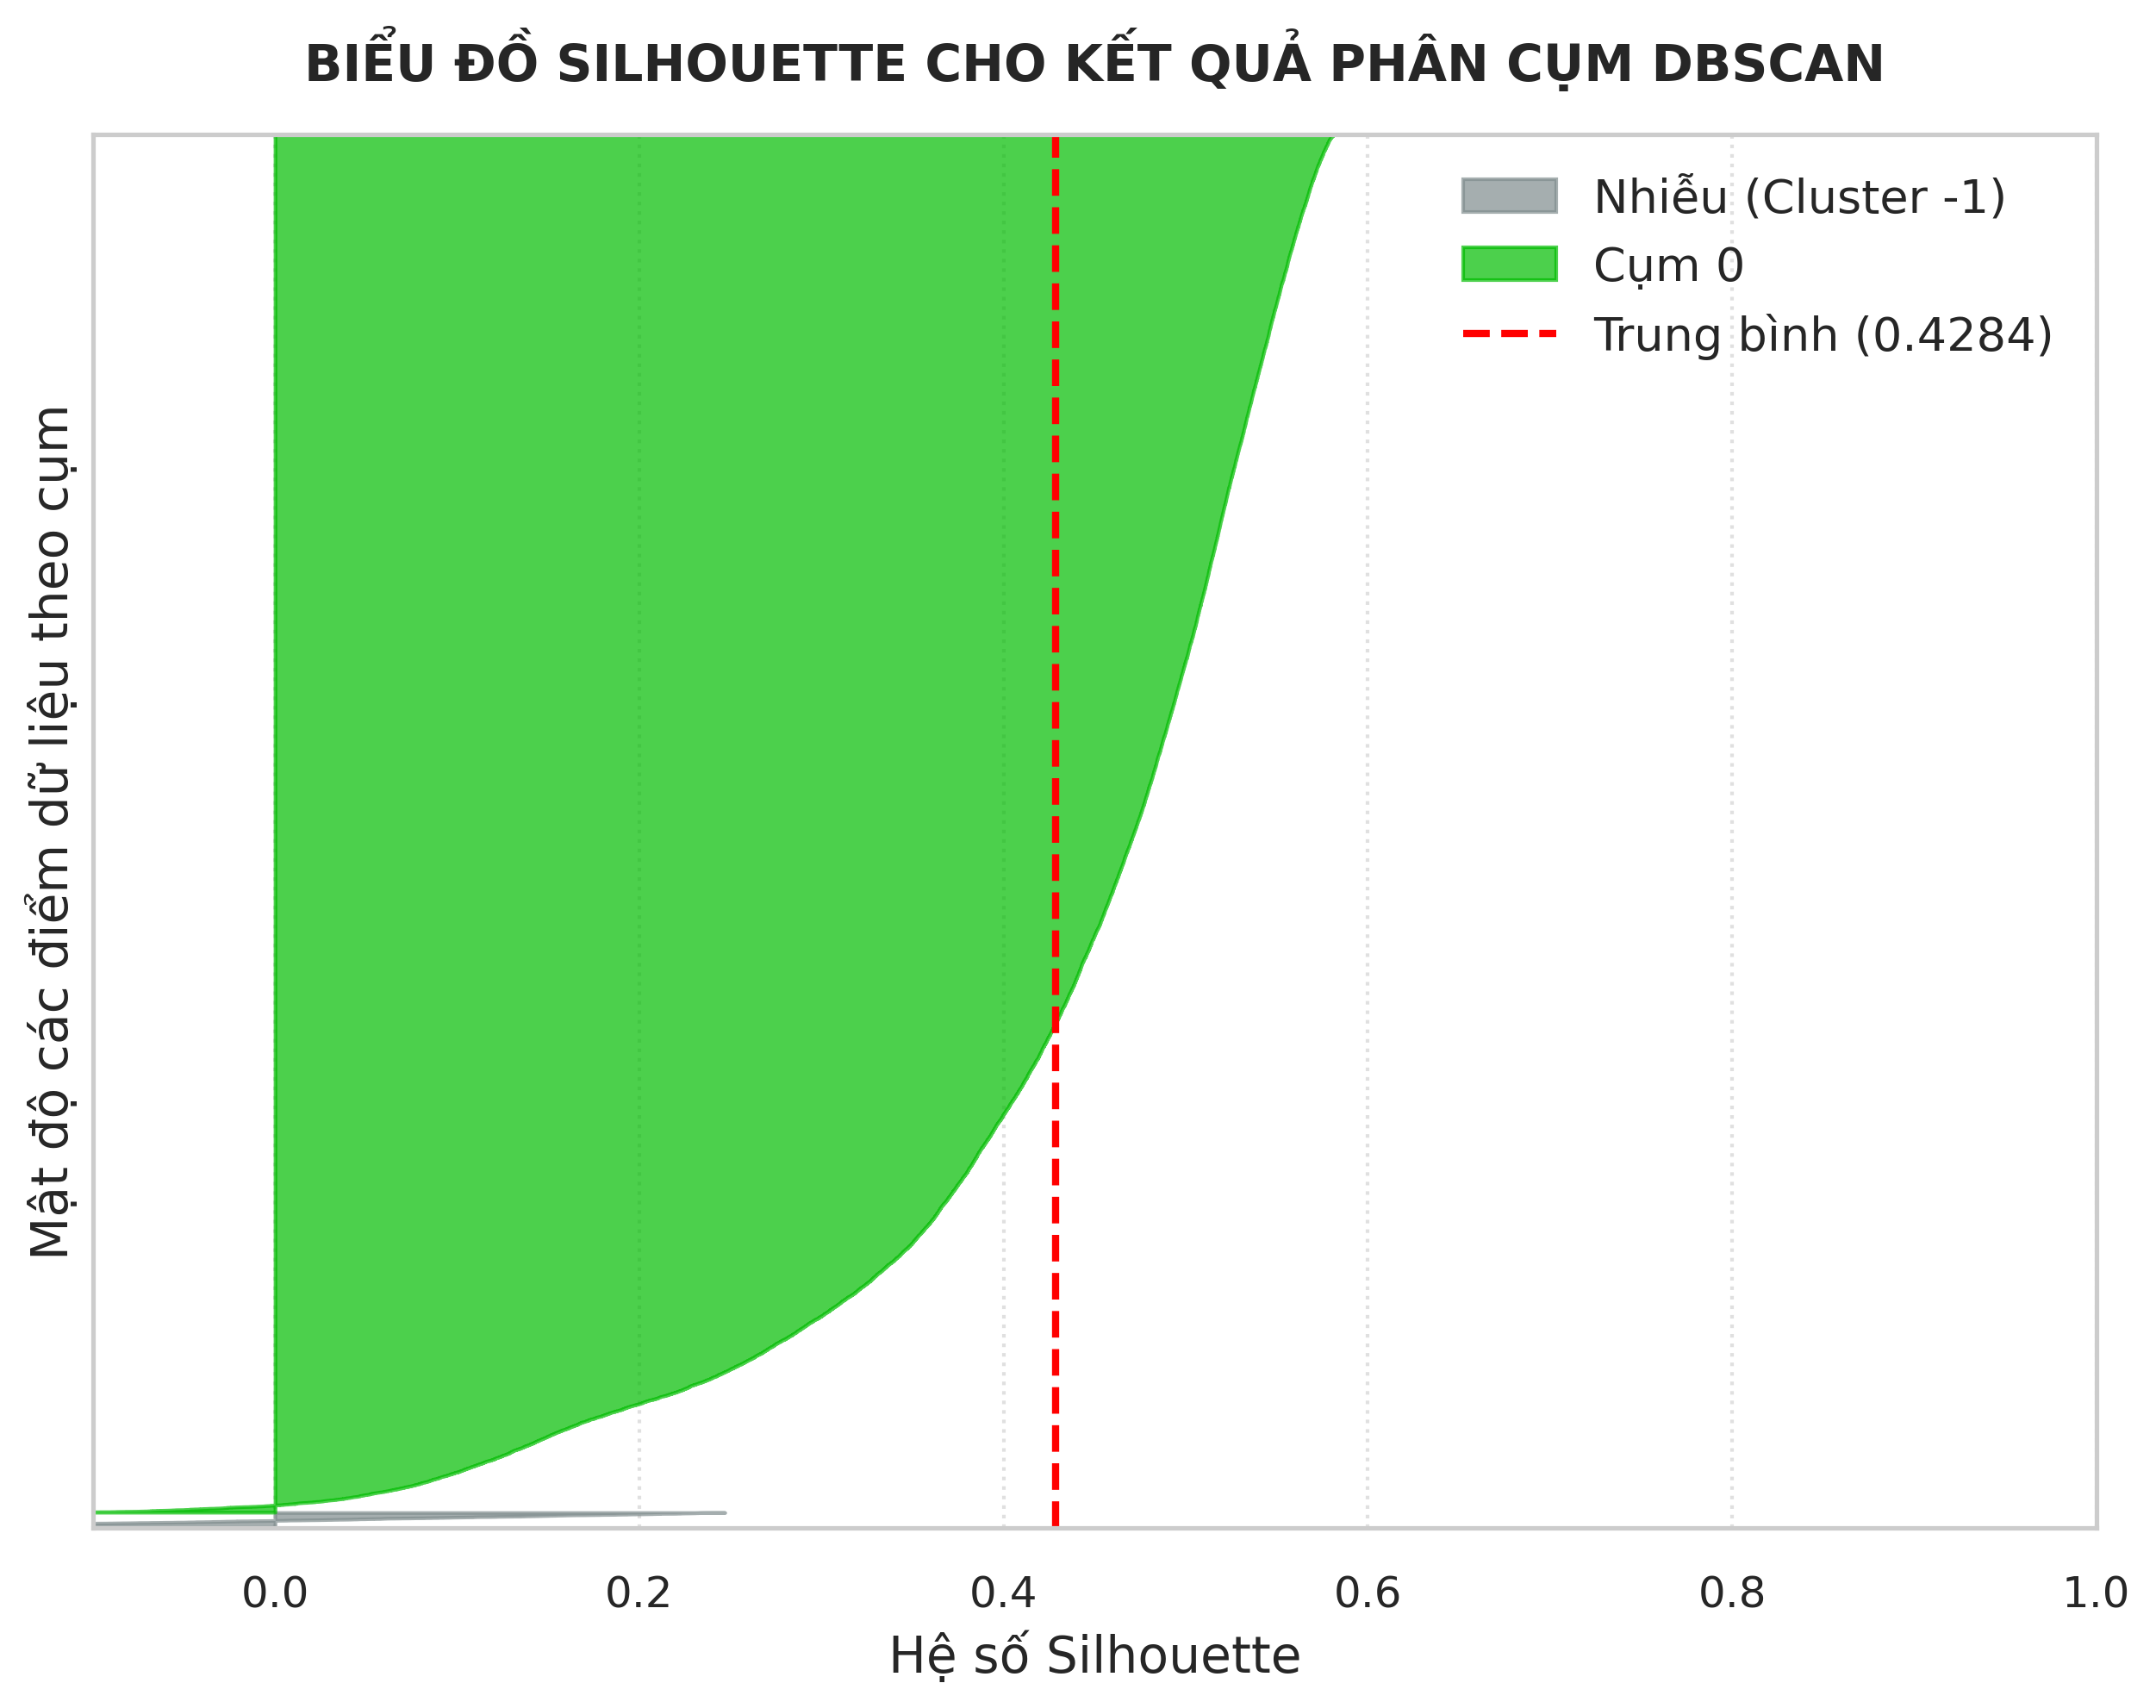

In [38]:
# 1. Tạo khung đồ thị
fig, ax1 = plt.subplots(1, 1, figsize=(10, 7))
ax1.set_xlim([-0.1, 1.0])  # Hệ số Silhouette nằm trong khoảng [-1, 1]

# Cấu hình khoảng trống trục Y dựa trên số lượng mẫu và số cụm
ax1.set_ylim([0, len(X_sample_metrics) + (len(np.unique(labels_sample_metrics)) + 1) * 10])

# 2. Tính toán giá trị Silhouette cho từng mẫu một (Dùng biến mẫu 50k dòng của bạn)
sample_silhouette_values = silhouette_samples(X_sample_metrics, labels_sample_metrics)

y_lower = 10
unique_labels = np.unique(labels_sample_metrics)

# 3. Vòng lặp vẽ "bản dẹt" mật độ cho từng cụm
for i, cluster in enumerate(unique_labels):
    # Lọc ra các giá trị silhouette thuộc về cụm hiện tại
    cluster_silhouette_values = sample_silhouette_values[labels_sample_metrics == cluster]
    cluster_silhouette_values.sort()  # Sắp xếp tăng dần để tạo hình lưỡi dao/bánh xoài
    
    size_cluster_i = cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    # Định dạng màu sắc: Cụm -1 (Nhiễu) tô màu xám, các cụm chuẩn tô màu theo phổ nipy_spectral
    if cluster == -1:
        color = '#7f8c8d'
        label_text = 'Nhiễu (Cluster -1)'
    else:
        color = cm.nipy_spectral(float(i) / len(unique_labels))
        label_text = f'Cụm {cluster}'

    # Đổ màu vùng biểu đồ
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7, label=label_text)

    # Cập nhật vị trí đáy cho cụm tiếp theo
    y_lower = y_upper + 10

# 4. Trang trí biểu đồ
ax1.set_title("BIỂU ĐỒ SILHOUETTE CHO KẾT QUẢ PHÂN CỤM DBSCAN", fontweight='bold', fontsize=14, pad=15)
ax1.set_xlabel("Hệ số Silhouette")
ax1.set_ylabel("Mật độ các điểm dữ liệu theo cụm")

# Vẽ đường nét đứt màu đỏ thể hiện giá trị trung bình tổng thể (0.3651)
# Biến 'score' lấy từ kết quả silhouette_score ở ô [32] trên máy bạn
ax1.axvline(x=score, color="red", linestyle="--", linewidth=2, label=f'Trung bình ({score:.4f})')

ax1.set_yticks([])  # Ẩn các vạch tọa độ Y vì quá dày
ax1.legend(loc="upper right", shadow=True)
ax1.grid(True, linestyle=':', alpha=0.6)

# Lưu ảnh vào thư mục kết quả của bạn
output_img_path = f"/workspace/AnhKetQuaClustering/DBSCAN_{eps_value}EpsValue_Silhouette_Graph.png"
plt.savefig(output_img_path, dpi=300, bbox_inches='tight')
print(f"-> Đã lưu biểu đồ thành công tại: {output_img_path}")

plt.show()

In [39]:
# Lưu lại tập dữ liệu tính toán (X) và nhãn tương ứng (Cluster) mà DBSCAN vừa gán
joblib.dump(X, f'/workspace/DBSCAN_{eps_value}EpsValue_X_features.pkl')
joblib.dump(df['Cluster'].values, f'/workspace/DBSCAN_{eps_value}EpsValue_labels.pkl')
print("Đã lưu bộ nhớ phân cụm DBSCAN thành công!")

Đã lưu bộ nhớ phân cụm DBSCAN thành công!
